<a href="https://colab.research.google.com/github/Anishka125/Medical-Insurance-Cost-predictor/blob/main/LinearREGRESSIONf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression using a SINGLE FEATURE

In [ ]:
%pip install opendatasets -U -q

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/harshsingh2209/medical-insurance-payout")

Skipping, found downloaded files in "./medical-insurance-payout" (use force=True to force download)


In [ ]:
import os
os.listdir("/content/medical-insurance-payout")

['expenses.csv']

In [ ]:
import pandas as pd
df = pd.read_csv("/content/medical-insurance-payout/expenses.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
!pip install plotly matplotlib seaborn --quiet

In [ ]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
non_smoker_df = df[df["smoker"] == "no"]


<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

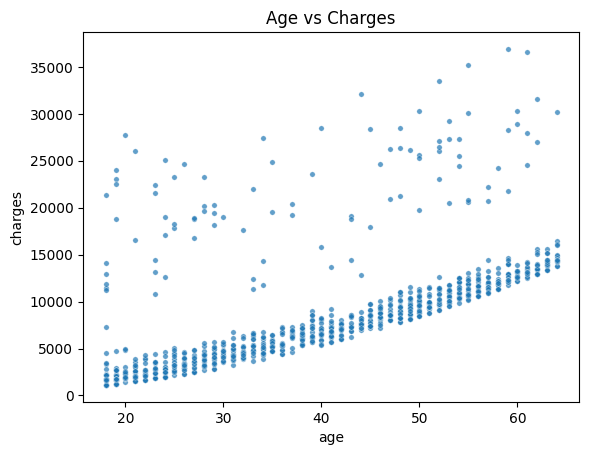

In [ ]:
plt.title('Age vs Charges')
sns.scatterplot(x='age', y='charges', data=non_smoker_df,alpha=0.7,s=15)

In [ ]:
w = 250      # weight / slope
b = 1000     # bias / intercept


In [ ]:
def estimate_charges(age,w,b):
  return w*age+b

In [ ]:
predicted_charges = estimate_charges(30, w, b)
print(predicted_charges)


8500


In [ ]:
ages=non_smoker_df.age
ages

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [ ]:
estimated_charges = estimate_charges(ages,w,b)
estimated_charges

,age
1,5500
2,8000
3,9250
4,9000
5,8750
...,...
1332,14000
1333,13500
1334,5500
1335,5500


In [ ]:
non_smoker_df.charges

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


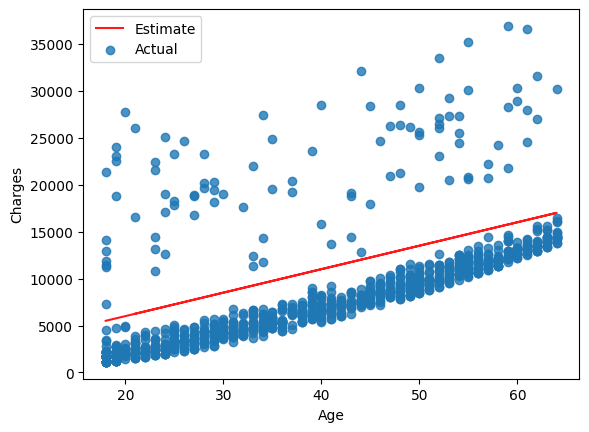

In [ ]:
target=non_smoker_df.charges
plt.plot(ages,estimated_charges,'r',alpha=0.9)
plt.scatter(ages,target,alpha=0.8)
plt.xlabel('Age');
plt.ylabel('Charges');
plt.legend(['Estimate','Actual'])

In [ ]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    predicted_charges = estimate_charges(ages, w, b)

    plt.plot(ages, predicted_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

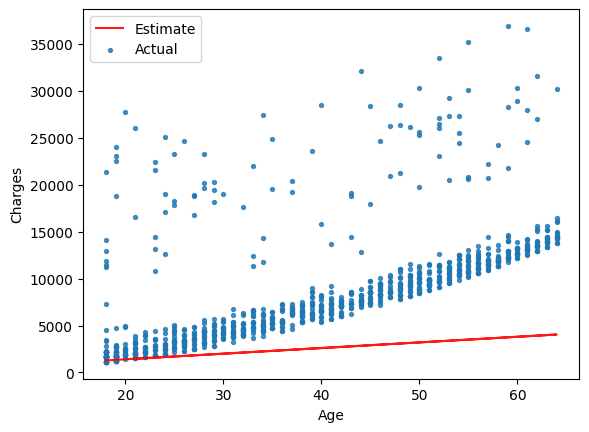

In [ ]:
try_parameters(60,200)

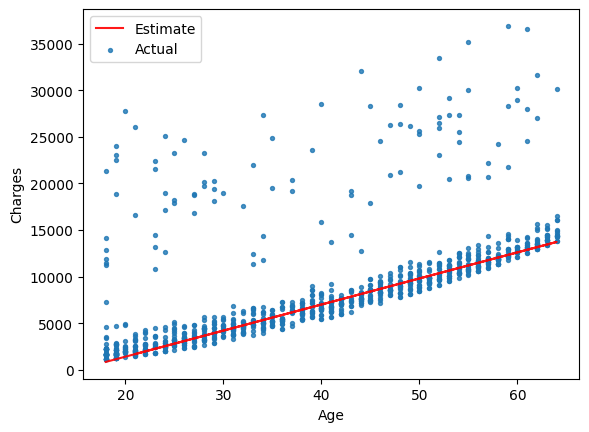

In [ ]:
try_parameters(280,-4200)

Loss/cost Function


In [ ]:
targets=non_smoker_df.charges
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


In [ ]:
predictions=estimated_charges
predictions

,age
1,5500
2,8000
3,9250
4,9000
5,8750
...,...
1332,14000
1333,13500
1334,5500
1335,5500


In [ ]:
!pip install numpy --quiet

In [ ]:
import numpy as np

 root mean squared error (RMSE).

In [ ]:
def rmse(targets,predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))

In [ ]:
w = 50
b = 100

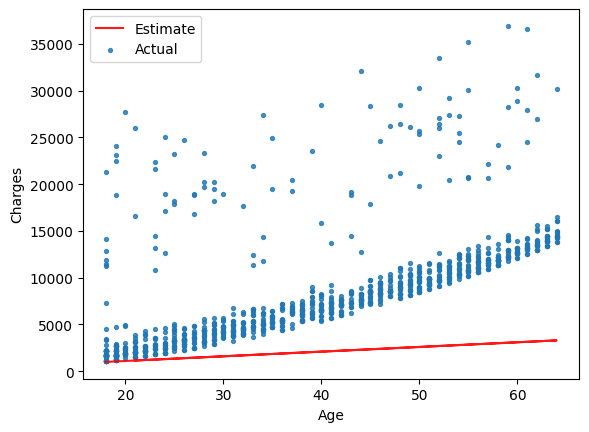

In [ ]:
try_parameters(w, b)

In [ ]:
targets = non_smoker_df['charges']
predicted_charges = estimate_charges(non_smoker_df.age, w, b)

In [ ]:
rmse(targets, predicted_charges)

np.float64(8461.949562575493)

In [ ]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predicted_charges = estimate_charges(ages, w, b)

    plt.plot(ages, predicted_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predicted_charges)
    print("RMSE Loss: ", loss)

RMSE Loss:  4689.0408418137085


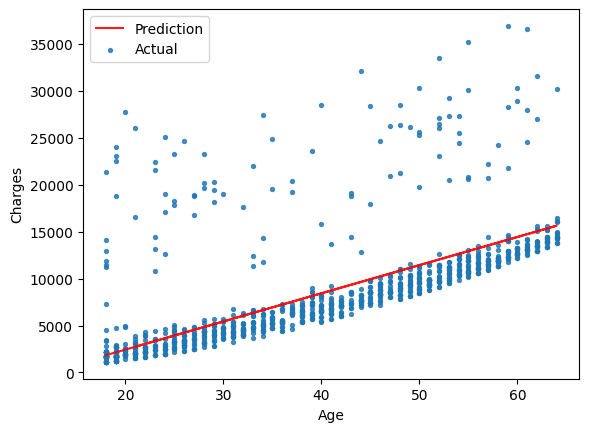

In [ ]:
try_parameters(300,-3570)

Ordinary Least Squares: https://www.youtube.com/watch?v=szXbuO3bVRk (better for smaller datasets)
Stochastic gradient descent: https://www.youtube.com/watch?v=sDv4f4s2SB8 (better for larger datasets)

Linear Regression class


Linear regression using scikit learn


In [ ]:
!pip install scikit-learn --quiet

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [ ]:
inputs

NameError: name 'inputs' is not defined

In [ ]:
type(inputs)

pandas.core.frame.DataFrame

In [ ]:
inputs.shape

(1064, 1)

In [ ]:
inputs=non_smoker_df[['age']]
targets=non_smoker_df['charges']
print('inputs.shape:',inputs.shape)
print('targets.shape:',targets.shape)
inputs.shape:(1064,)
targets.shape:(1064,)

inputs.shape: (1064, 1)
targets.shape: (1064,)


In [ ]:
model.fit(inputs,targets)

LinearRegression()

In [ ]:
model.predict(np.array([[23],
                        [37],
                        [61]]   ))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [ ]:
predictions=model.predict(inputs)

In [ ]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [ ]:
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


In [ ]:
rmse(targets,predictions)

np.float64(4662.505766636395)

In [ ]:
#w
model.coef_

array([267.24891283])

In [ ]:
#b
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss:  4662.505766636395


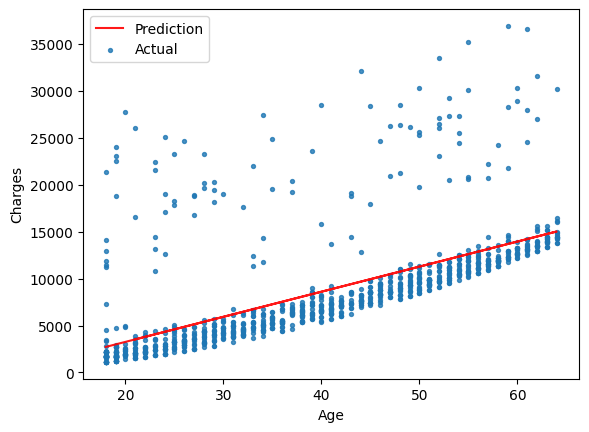

In [ ]:
try_parameters(model.coef_,model.intercept_)

SGDRegressor is a linear regression model that is trained using Stochastic Gradient Descent (SGD).

🔹 What is SGDRegressor?

It learns a linear model:

𝑦=𝑤1𝑥1+𝑤2𝑥2+⋯+𝑏


Uses SGD → updates weights one sample at a time

Very efficient for large datasets

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.metrics import root_mean_squared_error

| Parameter       |    Meaning                                                          |
| --------------- | ---------------------------------------------------------------- |
| `max_iter`      | Number of passes over the dataset                                |
| `eta0`          | Initial learning rate                                            |
| `learning_rate` | How learning rate changes (`constant`, `invscaling`, `adaptive`) |
| `loss`          | Loss function (`squared_error` for regression)                   |
| `penalty`       | Regularization (`l2`, `l1`, `elasticnet`)                        |
| `alpha`         | Regularization strength                                          |
| `random_state`  | Ensures reproducibility                                          |


max_iter

How many times the model learns from the data

More iterations → model learns more

Too few → model learns poorly

🧠 Think: number of study rounds before an exam

🔹 eta0

Starting learning speed

Controls how big each step is while learning

Too high → model jumps and misses the answer

Too low → model learns very slowly

🧠 Think: walking speed while finding a destination

🔹 learning_rate

How the learning speed changes

constant → same speed every time

invscaling → speed slowly decreases

adaptive → slows down when learning stops improving

🧠 Think: slowing down when you get close to your goal

🔹 loss

What mistake the model tries to reduce

squared_error → squares mistakes (common for regression)

Bigger mistakes are punished more

🧠 Think: how strictly mistakes are counted

🔹 penalty

Prevents overfitting

l2 → keeps weights small (most common)

l1 → can remove useless features

elasticnet → mix of both

🧠 Think: discipline rule to stop over-learning

🔹 alpha

Strength of the penalty

Small value → little restriction

Large value → strong restriction

🧠 Think: how strict the discipline is

🔹 random_state

Keeps results the same every time

Fixes randomness in training

Helps in debugging and comparison

🧠 Think: using the same question paper every time

In [ ]:
X = df[['age']]      # must be 2D
y = df['charges']


In [ ]:
model = SGDRegressor(
    max_iter=1000,
    learning_rate='invscaling',
    eta0=0.01,
    random_state=42,
    alpha=0.0001,
    tol=1e-3
)

model.fit(inputs,targets)


SGDRegressor(random_state=42)

In [ ]:
scaler = StandardScaler()
inputs_scaled = scaler.fit_transform(X)

In [ ]:
targets_pred = model.predict(inputs)


In [ ]:
targets_pred

array([3360.42424533, 5188.23936203, 6102.14692038, ..., 3360.42424533,
       3360.42424533, 3908.76878034])

In [ ]:
rmse = root_mean_squared_error(targets,targets_pred)


In [ ]:
rmse

4950.755108149788

Every machine learning problem has three components:

Model

Cost Function

Optimizer

# Create inputs and targets
inputs, targets = non_smoker_df[['age']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

**Linear Regression using Multiple Features**

charges=w1×age+w2×bmi+b

We need to change just one line of code to include the BMI.

# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']


In [ ]:
inputs,targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']

In [ ]:
model = LinearRegression().fit(inputs, targets)

In [ ]:
predictions = model.predict(inputs)


In [ ]:
from sklearn.metrics import root_mean_squared_error
loss = root_mean_squared_error(targets, predictions)

In [ ]:
loss

4662.3128354612945

In [ ]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [ ]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
fig = px.scatter_3d(non_smoker_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

In [ ]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply.

charges=w
1
​
 ×age+w
2
​
 ×bmi+w
3
​
 ×charges+b

In [ ]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [ ]:
fig = px.strip(non_smoker_df, x='children', y='charges', title= "Children vs. Charges")
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

1️⃣ Scatter Plot

What it shows:
Relationship between two numerical variables

Use:

Find correlation

See trends & patterns

Detect outliers

Example: Age vs Charges

plt.scatter(x, y)

2️⃣ Line Plot

What it shows:
Change of values over time or sequence

Use:

Trend analysis

Time-series data

plt.plot(x, y)

3️⃣ Bar Plot

What it shows:
Comparison between categories

Use:

Compare averages or counts

Categorical vs numerical data

plt.bar(categories, values)

4️⃣ Histogram

What it shows:
Distribution of a single numerical variable

Use:

Understand data spread

Check skewness

plt.hist(data, bins=10)

5️⃣ Box Plot

What it shows:

Median

Quartiles

Outliers

Use:

Detect outliers

Compare distributions

plt.boxplot(data)

6️⃣ Violin Plot

What it shows:

Distribution shape + density

Combines box plot + KDE

Use:

Compare distributions between groups

Better than box plot when shape matters

sns.violinplot(x=cat, y=num)

7️⃣ Strip Plot

What it shows:

Individual data points

No aggregation

Use:

See exact values

Best for small datasets

sns.stripplot(x=cat, y=num, jitter=True)

8️⃣ Swarm Plot

What it shows:

Like strip plot but points don’t overlap

Use:

Clear visualization of individual values

sns.swarmplot(x=cat, y=num)

9️⃣ Heatmap

What it shows:
Values using colors

Use:

Correlation matrix

Pattern detection

sns.heatmap(data, annot=True)

🔟 Pair Plot

What it shows:
All pairwise relationships in data

Use:

Quick EDA (Exploratory Data Analysis)

sns.pairplot(df)

In [ ]:
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']


In [ ]:
model = LinearRegression().fit(inputs, targets)


In [ ]:
predictions = model.predict(inputs)


In [ ]:
from sklearn.metrics import root_mean_squared_error
loss = root_mean_squared_error(targets, predictions)

In [ ]:
loss

4608.470405038247

In [ ]:
inputs, targets = df[['age', 'bmi', 'children']], df['charges']

In [ ]:
model = LinearRegression().fit(inputs, targets)


In [ ]:
predictions = model.predict(inputs)

In [ ]:
from sklearn.metrics import root_mean_squared_error
loss = root_mean_squared_error(targets, predictions)

In [ ]:
loss

11355.317901125973

Using Categorical Features for Machine Learning
So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1.

If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s.

If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals

Binary Categories

<Axes: xlabel='smoker', ylabel='charges'>

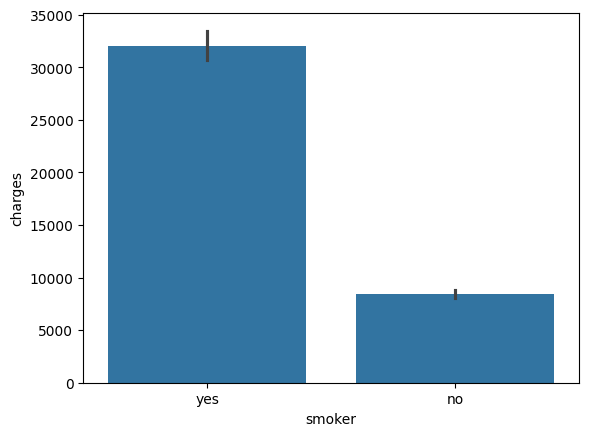

In [ ]:
sns.barplot(data=df, x='smoker', y='charges')

In [ ]:
smoker_codes = {'yes': 1, 'no': 0}
df['smoker_code'] = df.smoker.map(smoker_codes)

In [ ]:
df.charges.corr(df.smoker_code)

np.float64(0.787251430498478)

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


<Axes: xlabel='sex', ylabel='charges'>

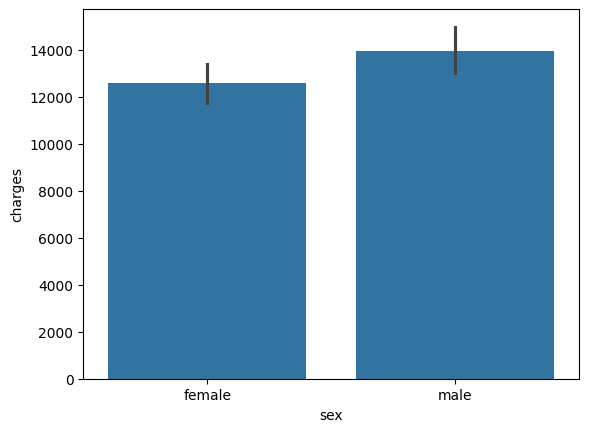

In [ ]:
sns.barplot(data=df, x='sex', y='charges')

In [ ]:
sex_codes={'male':1,'female':0}
df['sex_code']=df.sex.map(sex_codes)

In [ ]:
df.charges.corr(df.sex_code)

np.float64(0.057292062202025484)

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


charges=w
1
​
 ×age+w
2
​
 ×bmi+w
3
​
 ×charges+w
4
​
 ×smoker+b

In [ ]:
inputs, targets = df[['age', 'bmi', 'children', 'smoker_code']],df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)



In [ ]:
predictions

array([25587.42524891,  3880.94594512,  7158.62006921, ...,
        4398.7459491 ,  1615.83647369, 36793.67069541])

In [ ]:

loss = root_mean_squared_error(targets, predictions)

In [ ]:
loss

6056.439217188081

HOT ENCODING

The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

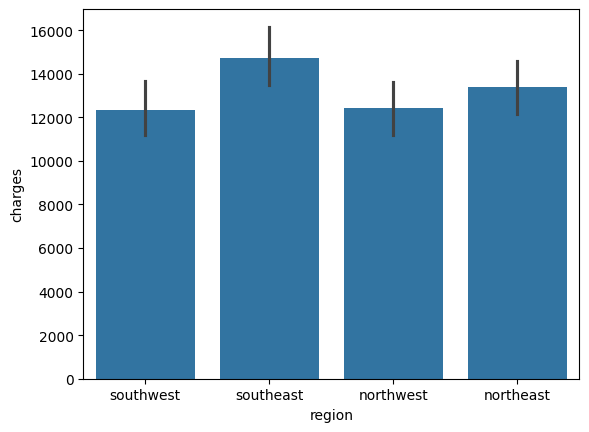

In [ ]:
sns.barplot(data=df, x='region', y='charges');


In [ ]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
one_hot = enc.transform(df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [ ]:
df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


charges=w
1
​
 ×age+w
2
​
 ×bmi+w
3
​
 ×charges+w
4
​
 ×smoker+w
5
​
 ×sex+w
6
​
 ×region+b



In [ ]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = df[input_cols],df['charges']


In [ ]:
model = LinearRegression().fit(inputs, targets)


In [ ]:
predictions = model.predict(inputs)

In [ ]:
loss = root_mean_squared_error(targets, predictions)

In [ ]:
loss

6041.6796511744515

**Model Improvements
Let's discuss and apply some more improvements to our model.

Feature Scaling**

charges=w
1
​
 ×age+w
2
​
 ×bmi+w
3
​
 ×charges+w
4
​
 ×smoker+w
5
​
 ×sex+w
6
​
 ×region+b

In [ ]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [ ]:
model.intercept_

np.float64(-12525.547811195444)

In [ ]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df


,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


While it seems like BMI and the "northeast" have a higher weight than age, keep in mind that the range of values for BMI is limited (15 to 40) and the "northeast" column only takes the values 0 and 1.

Because different columns have different ranges, we run into two issues:

We can't compare the weights of different column to identify which features are important
A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process.

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(df[numeric_cols])

StandardScaler()

In [ ]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [ ]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [ ]:
scaled_inputs = scaler.transform(df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [ ]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = df[cat_cols].values

In [ ]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = df.charges

In [ ]:
model = LinearRegression().fit(inputs, targets)


In [ ]:
model = LinearRegression().fit(inputs, targets)


In [ ]:
loss=root_mean_squared_error(targets, predictions)

In [ ]:
loss

6041.6796511744515

We can now compare the weights in the formula:

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [ ]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)


,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


In [ ]:
new_customers=[[28,30,2,1,0,0,1,0,0.]]
scaler.transform([[28,30,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-0.79795355, -0.10882659,  0.75107928]])

In [ ]:
model.predict([[-0.79795355, -0.10882659,  0.75107928,1,0,0,1,0,0.]])

array([29875.81463371])

Creating Test Set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.2)

In [ ]:
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)


In [ ]:
loss=root_mean_squared_error(targets_test, predictions_test)

In [ ]:
loss

6027.120775681997

In [ ]:
predictions_train = model.predict(inputs_train)


In [ ]:
loss=root_mean_squared_error(targets_train, predictions_train)

In [ ]:
loss

5948.137761857877